In [1]:
# import zipfile

# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# # Unzip the downloaded file
# zip_ref = zipfile.ZipFile("pizza_steak.zip")
# zip_ref.extractall()
# zip_ref.close()

In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [3]:
print("TF version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TF version: 2.16.2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import urllib.request

url = "https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip"
urllib.request.urlretrieve(url, "pizza_steak.zip")

('pizza_steak.zip', <http.client.HTTPMessage at 0x13f6a3710>)

In [ ]:
import os
print(os.path.getsize("pizza_steak.zip"))

109540975


In [25]:
# from pathlib import Path

# p = Path("pizza_steak.zip")
# print(p)

In [7]:
import zipfile
# Unzip the downloaded file
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

In [8]:
!ls pizza_steak

test  train


In [9]:
!ls pizza_steak/test/

pizza steak


In [10]:
!ls pizza_steak/train/pizza/

1008104.jpg 1638227.jpg 2235981.jpg 2774899.jpg 3464027.jpg 576236.jpg
1008144.jpg 1646974.jpg 2236914.jpg 2775763.jpg 3464858.jpg 5764.jpg
1008844.jpg 1649108.jpg 2241448.jpg 2778214.jpg 3473991.jpg 579691.jpg
1008941.jpg 1649276.jpg 2247711.jpg 277963.jpg  3475936.jpg 593400.jpg
1011404.jpg 1652943.jpg 2253670.jpg 2785084.jpg 3478964.jpg 59445.jpg
102037.jpg  1654444.jpg 2255361.jpg 2793535.jpg 3479875.jpg 596494.jpg
1026922.jpg 1660415.jpg 2274117.jpg 27963.jpg   3479936.jpg 598381.jpg
1029698.jpg 1663749.jpg 2279642.jpg 2800325.jpg 3484590.jpg 604977.jpg
1033251.jpg 1665654.jpg 2280345.jpg 2811032.jpg 3493457.jpg 608085.jpg
1035854.jpg 166823.jpg  2285269.jpg 282013.jpg  349946.jpg  618021.jpg
1038357.jpg 1670471.jpg 2285942.jpg 2821034.jpg 350358.jpg  61822.jpg
1040878.jpg 1671531.jpg 228778.jpg  2821048.jpg 3505182.jpg 618348.jpg
1044524.jpg 1678284.jpg 2291093.jpg 2827938.jpg 3512070.jpg 625687.jpg
1044789.jpg 1681043.jpg 2292986.jpg 2831983.jpg 3514408.jpg 626170.jpg
1047561.jp

In [11]:
import os

# Walk through pizza_steak directory and list number of files
for dirpath,dirnames,filenames in os.walk('pizza_steak'):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak/test'.
There are 0 directories and 250 images in 'pizza_steak/test/steak'.
There are 0 directories and 250 images in 'pizza_steak/test/pizza'.
There are 2 directories and 0 images in 'pizza_steak/train'.
There are 0 directories and 750 images in 'pizza_steak/train/steak'.
There are 0 directories and 750 images in 'pizza_steak/train/pizza'.


In [12]:
# The extra file in our pizza_steak directory is ".DS_Store"
!ls -la pizza_steak

total 0
drwxr-xr-x@  4 fahimp  staff  128 Apr 15 13:22 .
drwxr-xr-x@ 13 fahimp  staff  416 Apr 15 13:22 ..
drwxr-xr-x@  4 fahimp  staff  128 Apr 15 13:22 test
drwxr-xr-x@  4 fahimp  staff  128 Apr 15 13:22 train


In [13]:
# Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))
num_steak_images_train

750

In [14]:
# Get the classnames programmatically
import pathlib
import numpy as np

data_dir = pathlib.Path('pizza_steak/train')
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))# Created a list of class_names from the subdirectories
print(class_names)

['pizza' 'steak']


In [15]:
# Let's visualize our images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir,target_class):
    # Setup the target directory (we'll view images from here)
    target__folder = target_dir+target_class

    #Get a random image path
    random_image = random.sample(os.listdir(target__folder),1)
    print(random_image)

    # Read in the image and plot it using matplotlib
    img = mpimg.imread(target__folder+'/'+random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis('off');

    print(f'Image shape : {img.shape}') # Show the shape of the image

    return img

['1267359.jpg']
Image shape : (512, 384, 3)


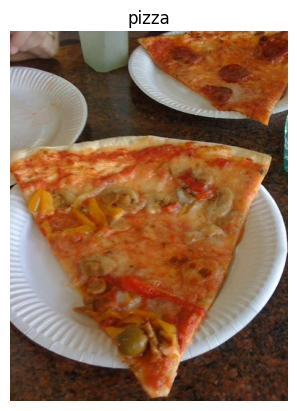

In [16]:
# View a random image from the training dataset
img = view_random_image(target_dir='pizza_steak/train/',
                        target_class='pizza')

In [17]:
224,224,3

(224, 224, 3)

In [18]:
# The images we've imported and plotted are actually giant arrays/tensors of different pixel values
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.constant(img)

Num GPUs Available: 1


2026-04-15 13:22:28.036349: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-15 13:22:28.036689: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-15 13:22:28.037223: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-15 13:22:28.037291: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-15 13:22:28.037836: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


<tf.Tensor: shape=(512, 384, 3), dtype=uint8, numpy=
array([[[125,  90,  71],
        [129,  94,  75],
        [137,  98,  81],
        ...,
        [129,  37,  14],
        [140,  44,  22],
        [151,  55,  33]],

       [[129,  94,  75],
        [130,  93,  75],
        [131,  92,  75],
        ...,
        [134,  44,  18],
        [142,  51,  24],
        [150,  59,  32]],

       [[130,  93,  77],
        [133,  96,  80],
        [134,  95,  80],
        ...,
        [137,  53,  19],
        [143,  59,  23],
        [148,  64,  28]],

       ...,

       [[ 53,  36,  26],
        [ 54,  38,  25],
        [ 56,  38,  26],
        ...,
        [ 62,  38,  28],
        [ 63,  36,  25],
        [ 61,  33,  22]],

       [[ 61,  43,  33],
        [ 59,  41,  29],
        [ 59,  39,  28],
        ...,
        [ 65,  38,  29],
        [ 68,  38,  28],
        [ 67,  37,  26]],

       [[ 69,  51,  41],
        [ 64,  46,  34],
        [ 62,  42,  31],
        ...,
        [ 67,  39,  2

In [19]:
# View the image shape
img.shape # returns width, height, colour channels

(512, 384, 3)

In [20]:
# Get all the pixel values between 0 & 1 (scale/normalize the data, as neural networks love values between 0 & 1)
img/255

array([[[0.49019608, 0.35294118, 0.27843137],
        [0.50588235, 0.36862745, 0.29411765],
        [0.5372549 , 0.38431373, 0.31764706],
        ...,
        [0.50588235, 0.14509804, 0.05490196],
        [0.54901961, 0.17254902, 0.08627451],
        [0.59215686, 0.21568627, 0.12941176]],

       [[0.50588235, 0.36862745, 0.29411765],
        [0.50980392, 0.36470588, 0.29411765],
        [0.51372549, 0.36078431, 0.29411765],
        ...,
        [0.5254902 , 0.17254902, 0.07058824],
        [0.55686275, 0.2       , 0.09411765],
        [0.58823529, 0.23137255, 0.1254902 ]],

       [[0.50980392, 0.36470588, 0.30196078],
        [0.52156863, 0.37647059, 0.31372549],
        [0.5254902 , 0.37254902, 0.31372549],
        ...,
        [0.5372549 , 0.20784314, 0.0745098 ],
        [0.56078431, 0.23137255, 0.09019608],
        [0.58039216, 0.25098039, 0.10980392]],

       ...,

       [[0.20784314, 0.14117647, 0.10196078],
        [0.21176471, 0.14901961, 0.09803922],
        [0.21960784, 0

### An end-to-end example
Let's build a convolutional neural network to find patterns in our images, more specifically we a need way to:

- Load our images
- Preprocess our images
- Build a CNN to find patterns in our images
- Compile our CNN
- Fit the CNN to our training data

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 0 & 1 ,also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = 'pizza_steak/train'
test_dir = 'pizza_steak/test'

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory = train_dir,
                                               batch_size = 32,
                                               target_size =(224,224),
                                               class_mode = 'binary',
                                               seed = 42)
valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size = 32,
                                               target_size=(224,224),
                                               class_mode = 'binary',
                                               seed = 42)

# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation='relu',
                           input_shape = (224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding = 'valid'),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

# Compile our CNN
model_1.compile(loss='binary_crossentropy',
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# Fit the  Model
history_1 = model_1.fit(train_data,
                        epochs = 5,
                        steps_per_epoch = len(train_data),
                        validation_data = valid_data,
                        validation_steps = len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/Users/fahimp/Desktop/Python_Frameworks/Deeplearning-with_tensorflow/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


2026-04-15 13:22:29.021046: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.6993 - loss: 0.5623 - val_accuracy: 0.8440 - val_loss: 0.3795
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7940 - loss: 0.4350 - val_accuracy: 0.8700 - val_loss: 0.3439
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.8460 - loss: 0.3639 - val_accuracy: 0.8760 - val_loss: 0.3035
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8540 - loss: 0.3572 - val_accuracy: 0.8080 - val_loss: 0.3966
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.8647 - loss: 0.3262 - val_accuracy: 0.8820 - val_loss: 0.3000


In [23]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)